In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
np.random.seed(0)
df = pd.DataFrame(
    data = {
        'Feature' : np.arange(1,101),
        'Target' : np.array([0]*60 + [1]*40)
    }
)
df.head()

,Feature,Target
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


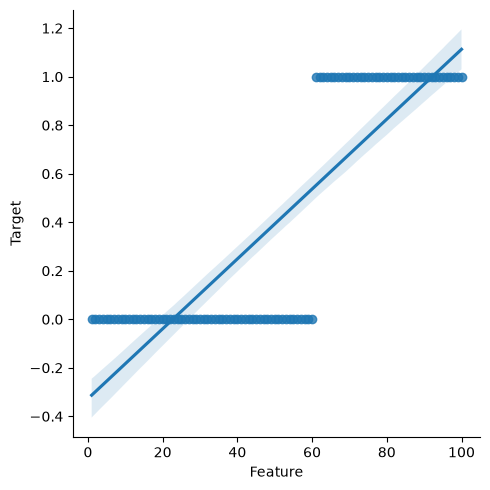

In [3]:
sns.lmplot(data=df, x = 'Feature', y='Target')

In [4]:
df_jitter = df.copy()
df_jitter['Target'] = df_jitter['Target'] + np.random.normal(0, 0.03, size=len(df))

df_jitter['Target'] = df_jitter['Target'].clip(0,1)

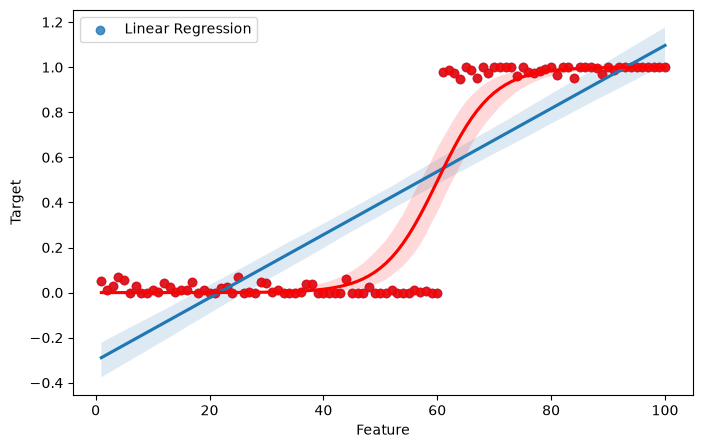

In [5]:
plt.figure(figsize=(8,5))
sns.regplot(
    data=df_jitter, 
    x = 'Feature', 
    y='Target',
    label='Linear Regression',

)
sns.regplot(
    data=df_jitter, 
    x = 'Feature', 
    y='Target',
    logistic=True,
    color='red'
)
plt.legend()
plt.show()

In [6]:
data = pd.read_csv('titanic_test.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,1,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,0,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,1,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,0,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [8]:
data['Pclass'].unique()



array([3, 2, 1])

In [9]:
data['Embarked'].unique()

<StringArray>
['Q', 'S', 'C']
Length: 3, dtype: str

In [10]:
data.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
413,False,False,False,False,False,True,False,False,False,False,True,False
414,False,False,False,False,False,False,False,False,False,False,False,False
415,False,False,False,False,False,False,False,False,False,False,True,False
416,False,False,False,False,False,True,False,False,False,False,True,False


<Axes: >

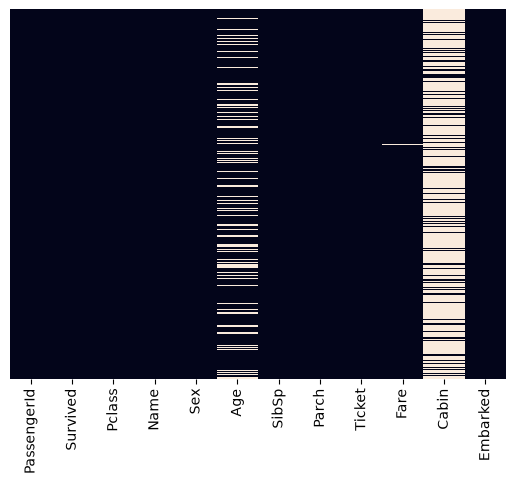

In [11]:
sns.heatmap(data.isnull(), yticklabels=False, cbar = False)

In [12]:
data.drop(columns=['Cabin'], inplace=True)

<Axes: >

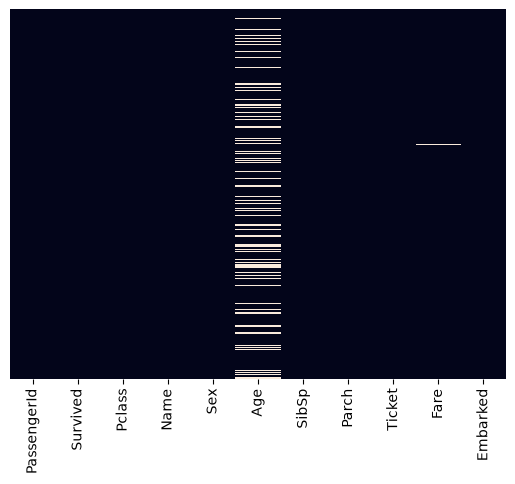

In [13]:
sns.heatmap(data.isnull(), yticklabels=False, cbar = False)


<Axes: xlabel='Sex', ylabel='Age'>

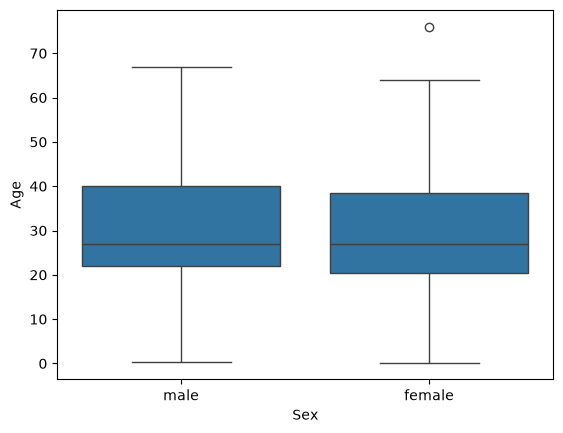

In [14]:
sns.boxplot(data=data, x='Sex', y='Age')

In [15]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 36.1 KB


<Axes: xlabel='Pclass', ylabel='Age'>

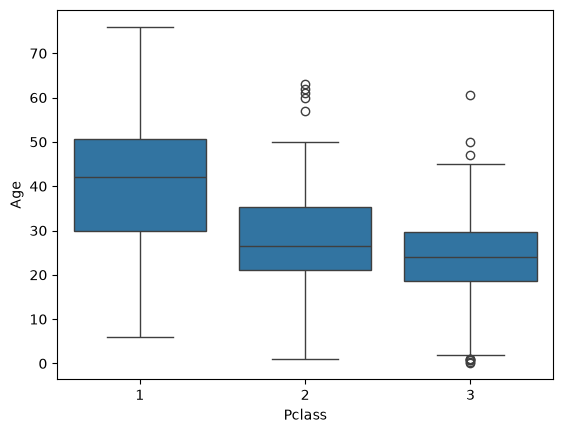

In [16]:
sns.boxplot(data=data, x='Pclass', y='Age')

In [17]:
pclass_1_median = data[data['Pclass']==1]['Age'].median()
pclass_2_median = data[data['Pclass']==2]['Age'].median()
pclass_3_median = data[data['Pclass']==3]['Age'].median()

pclass_1_median, pclass_2_median, pclass_3_median

(np.float64(42.0), np.float64(26.5), np.float64(24.0))

In [18]:
def fill_age(columns):
    age = columns.iloc[0]
    pclass = columns.iloc[1]

    if pd.isnull(age):

        if pclass ==1:
            return pclass_1_median
        elif pclass ==2:
            return pclass_2_median
        else:
            return pclass_3_median

    else:
        return age


In [19]:
data['Age'] = data[['Age','Pclass']].apply(fill_age, axis=1)

In [20]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 36.1 KB
